<a href="https://colab.research.google.com/github/Yuliia-Safonova/DTA-2026/blob/main/homework/practice_stat_tests_HARDER_19_06_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🎓 Статистичні тести: поглиблений практикум

**Рівень:** середній+ · фокус на **інтерпретації** · бібліотека `scipy.stats`

---

Цей практикум складніший за попередній. Тут менше «механічного» застосування тестів і більше **роздумів**: ви будете обирати тести самостійно, помічати пастки і — найголовніше — **пояснювати, що результат означає для бізнесу**.

### Що нового порівняно з минулим практикумом
- 🧠 Більшість завдань вимагають, щоб ви **самі обрали тест** і обґрунтували вибір.
- 🪤 Тут є **пастки**: випадки, де p < 0.05, але результат практично не важливий; де дані спотворені викидами; де результат «на межі».
- 💬 На кожне завдання — **розгорнута інтерпретація**. Саме це відрізняє аналітика від калькулятора.

### Як працювати
1. До кожного завдання є **підказки** — користуйтесь ними, але спершу подумайте самі.
2. Інтерпретації пишіть так, ніби пояснюєте керівнику **без** статистичної освіти.
3. Не зупиняйтесь на «p < 0.05, значущо» — завжди питайте: *наскільки великий ефект? чи це важливо на практиці? чи можна довіряти даним?*

> ⚠️ Головна теза практикуму: **статистична значущість ≠ практична важливість.** Тримайте це в голові протягом усієї роботи.

---

## Підготовка

Працюємо з даними SaaS-продукту (онлайн-сервіс за підпискою). Запустіть клітинку нижче.

**`saas_users.csv`** — 1200 користувачів:

| Стовпець | Опис | Тип |
|---|---|---|
| `user_id` | ID користувача | — |
| `plan` | Тариф (Free / Pro / Business) | категоріальний |
| `region` | Регіон (Europe / Americas / Asia) | категоріальний |
| `signup_source` | Джерело реєстрації (Search / Referral / Ads / Social) | категоріальний |
| `support_tickets` | Кількість звернень у підтримку | числовий |
| `weekly_sessions` | Сеансів на тиждень | числовий |
| `feature_adopted` | Чи почав користуватись новою функцією (Так/Ні) | категоріальний |
| `nps_before` | Оцінка лояльності NPS ДО оновлення (0-10) | числовий |
| `nps_after` | NPS ПІСЛЯ оновлення (0-10) | числовий |

**`onboarding_ab.csv`** — A/B-тест нового онбордингу (100 000 користувачів!):

| Стовпець | Опис |
|---|---|
| `user_id` | ID |
| `variant` | Control (старий онбординг) або Treatment (новий) |
| `signed_up` | Чи завершив реєстрацію (1/0) |


In [38]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

FILE_IN_1 = 'https://raw.githubusercontent.com/Yuliia-Safonova/DTA-2026/refs/heads/main/data/saas_users.csv'
FILE_IN_2 = 'https://raw.githubusercontent.com/Yuliia-Safonova/DTA-2026/refs/heads/main/data/onboarding_ab.csv'

users = pd.read_csv(FILE_IN_1)
ab = pd.read_csv(FILE_IN_2)

print("Користувачі:", users.shape)
print("\nA/B онбординг:", ab.shape)
print()
users.head()

Користувачі: (1200, 9)

A/B онбординг: (100000, 3)



,user_id,plan,region,signup_source,support_tickets,weekly_sessions,feature_adopted,nps_before,nps_after
0,10001,Free,Americas,Social,2,11,Так,5,3
1,10002,Pro,Asia,Search,12,16,Ні,6,3
2,10003,Free,Asia,Social,6,11,Ні,5,5
3,10004,Business,Americas,Referral,4,27,Ні,7,7
4,10005,Pro,Asia,Referral,1,8,Ні,4,6


---
# Розділ 1. Спочатку — подивись на дані уважно

## 🟦 Чому це важливо
Перш ніж застосовувати тести, аналітик завжди вивчає дані. Тести роблять припущення (наприклад, t-тест найкраще працює, коли дані приблизно симетричні). Якщо дані сильно спотворені викидами — середнє може вводити в оману, і висновок тесту теж.

#### ✏️ Завдання 1 (код)

Виведіть описову статистику (`.describe()`) для числових стовпців. Окремо порівняйте **середнє** і **медіану** стовпця `support_tickets`.

> 💡 **Підказка:** Для медіани: `users['support_tickets'].median()`. Зверніть увагу, чи сильно середнє відрізняється від медіани.

In [39]:
# Завдання 1:
# Описова статистика для всіх числових стовпців
users.describe()

mean_tickets = users['support_tickets'].mean()
median_tickets = users['support_tickets'].median()

print(f"Середнє: {mean_tickets:.2f}")
print(f"Медіана: {median_tickets:.2f}")

Середнє: 2.10
Медіана: 1.00


#### 💬 Інтерпретація 1

Порівняйте середнє і медіану `support_tickets`. Що це говорить про форму розподілу (чи є викиди — користувачі з дуже великою кількістю звернень)? Чому для такого стовпця варто бути обережним із t-тестом?

> 🧭 **Орієнтир для відповіді:** Якщо середнє помітно більше за медіану — розподіл «витягнутий» вправо (є кілька користувачів з дуже багатьма зверненнями). Подумайте, як викиди впливають на середнє.

*(Відповідайте у клітинці нижче повними реченнями, людською мовою.)*

**Ваша відповідь:**

Середнє значення кількості звернень у підтримку становить 2.10, а медіана — 1.00. Оскільки середнє помітно більше за медіану, розподіл support_tickets є витягнутим вправо. Це означає, що більшість користувачів мають небагато звернень у підтримку (0–1 звернення), але є невелика кількість користувачів із дуже великою кількістю звернень. Саме ці значення підвищують середнє. Така різниця між середнім і медіаною свідчить про можливу наявність викидів — користувачів, які зверталися до підтримки значно частіше за інших.

Для такого стовпця варто бути обережним із t-тестом, оскільки він передбачає приблизну нормальність розподілу даних у групах. Викиди та сильна асиметрія можуть суттєво впливати на середнє значення і, відповідно, на результати тесту. У таких випадках доцільно додатково перевіряти розподіл даних.

#### ✏️ Завдання 2 (код)

Побудуйте гістограму `support_tickets`, щоб побачити розподіл на власні очі.

> 💡 **Підказка:** `users['support_tickets'].plot(kind='hist', bins=20)` і потім `plt.show()`.

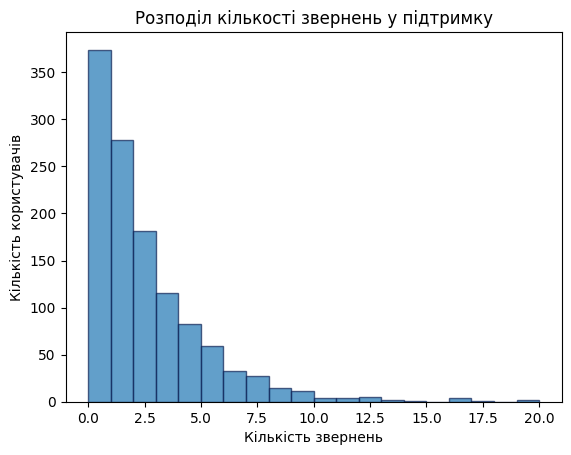

In [40]:
# Завдання 2:
users['support_tickets'].plot(kind='hist', bins=20, edgecolor='#0e2154', alpha=0.7)

plt.title('Розподіл кількості звернень у підтримку')
plt.xlabel('Кількість звернень')
plt.ylabel('Кількість користувачів')

plt.show()

#### 💬 Інтерпретація 2

Що видно на гістограмі? Підтверджує вона ваш висновок про викиди з попереднього завдання?

> 🧭 **Орієнтир для відповіді:** Опишіть форму: чи більшість значень малі, а «хвіст» тягнеться до великих? Це типовий скошений (skewed) розподіл.

*(Відповідайте у клітинці нижче повними реченнями, людською мовою.)*

**Ваша відповідь:**

Гістограма показує, що більшість користувачів мають дуже мало звернень у підтримку — переважно від 0 до 3. Частота спостережень швидко зменшується зі збільшенням кількості звернень.

При цьому праворуч видно довгий хвіст, який тягнеться приблизно до 20 звернень. Це означає, що існує невелика кількість користувачів із дуже великою кількістю звернень у підтримку.

Отже, гістограма підтверджує попередній висновок про наявність викидів. Саме ці користувачі з великою кількістю звернень підвищують середнє значення (2.10), через що воно є більшим за медіану (1.00).

Розподіл є правосторонньо скошеним (positive skew) і не схожий на нормальний. Тому при аналізі такого показника слід бути обережним із методами, які спираються на припущення про нормальність даних, зокрема з t-тестом. Для опису «типового» користувача в цьому випадку медіана є більш інформативною, ніж середнє.

---
# Розділ 2. Порівняння кількох груп — обери тест сам

## 🟦 Нагадування
Коли треба порівняти числову величину між **3+ групами**, згадайте, який тест підходить. Не забувайте: він каже лише, що різниця *десь є*, але не каже, *між якими саме* групами.

#### ✏️ Завдання 3 (код)

Користувачі різних тарифів (`plan`) можуть по-різному користуватись продуктом. Перевірте, чи відрізняється середня кількість сеансів на тиждень (`weekly_sessions`) між тарифами Free / Pro / Business. Спершу виведіть середні по групах, потім проведіть відповідний тест.

> 💡 **Підказка:** Три групи + числова змінна → ANOVA (`stats.f_oneway`). Зберіть групи у список: `[users[users.plan==p].weekly_sessions for p in users.plan.unique()]`.

In [41]:
# Завдання 3:
display(users.groupby('plan')['weekly_sessions'].mean().round(2))

groups = [users[users['plan'] == p]['weekly_sessions'] for p in users['plan'].unique()]

f_stat, p_value = stats.f_oneway(*groups)

print(f"\nF-статистика: {f_stat:.4f}")
print(f"\np-значення: {p_value:.2e}")

,weekly_sessions
plan,
Business,19.59
Free,7.93
Pro,13.30



F-статистика: 415.1936

p-значення: 1.09e-137


#### 💬 Інтерпретація 3

Чи відрізняються тарифи за активністю? Який тариф найактивніший? І ключове питання: чому за результатом ANOVA ви НЕ можете одразу стверджувати, що, наприклад, Pro значущо активніший за Free? Що для цього треба було б зробити додатково?

> 🧭 **Орієнтир для відповіді:** ANOVA виявляє різницю «хоча б десь». Для конкретних пар потрібні post-hoc тести (напр. Тьюкі) або попарні порівняння з поправкою на множинність.

*(Відповідайте у клітинці нижче повними реченнями, людською мовою.)*

**Ваша відповідь:**

Середня кількість сеансів на тиждень суттєво відрізняється між тарифними планами. Найактивнішими є користувачі тарифу Business, а найменш активними — користувачі тарифу Free.

Результат ANOVA показав, що якщо p < 0.05, нульову гіпотезу про рівність середніх відхиляємо. Це означає, що між тарифами існують статистично значущі відмінності в активності користувачів.

Проте за результатом ANOVA не можна одразу стверджувати, що саме тариф Pro значущо активніший за Free або що Business значущо активніший за Pro. ANOVA відповідає лише на запитання: «Чи є різниця хоча б між двома групами?», але не показує між якими саме. Щоб визначити, які конкретно пари тарифів відрізняються, потрібно виконати post-hoc аналіз, наприклад тест Тьюкі або попарні t-тести з поправкою на множинні порівняння.

Отже, ANOVA підтвердила наявність відмінностей між тарифами загалом, але для висновків щодо конкретних пар тарифів потрібні додаткові post-hoc тести.

#### ✏️ Завдання 4 (код)

Тепер перевірте, чи відрізняється `weekly_sessions` між регіонами (`region`).

> 💡 **Підказка:** Той самий тест, що й вище, але групуєте за `region`.

In [42]:
# Завдання 4:
display(users.groupby('region')['weekly_sessions'].mean().round(2))

groups = [users[users['region'] == r]['weekly_sessions'] for r in users['region'].unique()]

f_stat, p_value = stats.f_oneway(*groups)

print(f"\nF-статистика: {f_stat:.4f}")
print(f"\np-значення: {p_value:.2e}")

,weekly_sessions
region,
Americas,10.78
Asia,11.52
Europe,12.28



F-статистика: 5.5455

p-значення: 4.01e-03


#### 💬 Інтерпретація 4

Порівняйте цей результат із попереднім (тарифи). В одному випадку різниця значуща, в іншому — ні (або слабша). Що це означає для продукту: який фактор (тариф чи регіон) сильніше пов'язаний з активністю користувача?

> 🧭 **Орієнтир для відповіді:** Зверніть увагу не лише на сам факт значущості, а й на те, наскільки далекі середні між групами одне від одного.

*(Відповідайте у клітинці нижче повними реченнями, людською мовою.)*

**Ваша відповідь:**

В обох випадках (для тарифів та для регіонів) p < 0.05, тобто відмінності є статистично значущими. Однак важливо дивитися не лише на значущість, а й на розмір відмінностей між середніми.

Для тарифів різниця дуже велика:
- між Free і Business майже 12 сеансів на тиждень
- середні значення суттєво віддалені одне від одного

Для регіонів різниця набагато менша:
- між Americas і Europe лише близько 1.5 сеанса на тиждень

Тому, хоча регіон і має статистично значущий зв'язок з активністю користувачів, вплив тарифу значно сильніший.  

Висновок:  
Активність користувачів значно сильніше пов'язана з тарифним планом, ніж із регіоном. Користувачі Business та Pro користуються продуктом набагато активніше, ніж користувачі Free. Відмінності між регіонами існують, але вони відносно невеликі з практичної точки зору. Отже, для прогнозування та підвищення активності користувачів тариф є більш важливим фактором, ніж регіон.

---
# Розділ 3. До і після — і розмір ефекту

## 🟦 Новий акцент: розмір ефекту
Тут ви зустрінете важливу пастку. Тест може показати «значущо» (p < 0.05), але **величина зміни** може бути крихітною. Аналітик завжди дивиться на обидві речі: і p-значення, і **наскільки великий** ефект.

#### ✏️ Завдання 5 (код)

Компанія оновила онбординг і виміряла NPS (лояльність) тих самих користувачів до (`nps_before`) і після (`nps_after`). Проведіть відповідний тест. Додатково порахуйте **середню зміну** NPS (різницю after − before).

> 💡 **Підказка:** Ті самі користувачі двічі → парний t-тест (`stats.ttest_rel`). Середня зміна: `(users['nps_after'] - users['nps_before']).mean()`.

In [43]:
# Завдання 5:
# Середня зміна NPS
delta_nps = (users['nps_after'] - users['nps_before']).mean()
print(f"Середня зміна NPS: {delta_nps:.2f}")

# Парний t-тест
t_stat, p_value = stats.ttest_rel(users['nps_after'], users['nps_before'])

print(f"\nt-статистика: {t_stat:.4f}")
print(f"\np-значення: {p_value:.2e}")

Середня зміна NPS: 0.22

t-статистика: 5.4992

p-значення: 4.66e-08


#### 💬 Інтерпретація 5

Тут — важлива пастка. Подивіться на p-значення І на розмір зміни. Чи зміна статистично значуща? А наскільки вона велика в балах NPS? Чи варто компанії святкувати «значуще покращення», якщо середній NPS зріс лише на ~0.2 бала з 10? Сформулюйте збалансований висновок.

> 🧭 **Орієнтир для відповіді:** Розрізняйте «статистично значущо» (різниця не випадкова) і «практично важливо» (різниця достатньо велика, щоб мати сенс для бізнесу). Тут перше — так, а друге — під питанням.

*(Відповідайте у клітинці нижче повними реченнями, людською мовою.)*

**Ваша відповідь:**

1. Статистична значущість — так, ефект є - p-значення дуже мале (значно менше 0.05), тому ми відхиляємо нульову гіпотезу. Це означає, що різниця між nps_before і nps_after не випадкова і, ймовірно, пов’язана з оновленням продукту.

Висновок: зміна статистично значуща

2. Практична значущість — дуже слабка, хоча ефект статистично підтверджений, його розмір: +0.22 бала по шкалі 0–10. Це дуже маленьке покращення з бізнес-точки зору. Навіть при 1200 користувачах така різниця означає, що реальний вплив на лояльність клієнтів мінімальний.

Висновок: практична користь сумнівна

---

ЗАГАЛЬНИЙ висновок:

Оновлення онбордингу дало статистично надійний, але дуже малий позитивний ефект на NPS. Ми впевнені, що ефект існує, це не випадковість. Але сам ефект настільки малий, що його бізнес-цінність під питанням. Компанії не варто «святкувати» це як сильне покращення.  
Швидше це сигнал, що:
- онбординг працює дуже слабко
- NPS не дуже чутливий до змін
- потрібні більш суттєві продуктові зміни, щоб побачити реальний ріст

---
# Розділ 4. 🪤 Велика пастка: A/B-тест на 100 000 користувачів

## 🟦 Контекст
Це найважливіший розділ практикуму. Компанія протестувала новий онбординг (Treatment) проти старого (Control) на **100 тисячах** користувачів. Через величезний обсяг даних тут виявляється класична пастка статистики.

#### ✏️ Завдання 6 (код)

Порахуйте конверсію реєстрації (`signed_up`) для кожного варіанта (Control і Treatment). На скільки **відсоткових пунктів** відрізняється конверсія?

> 💡 **Підказка:** `ab.groupby('variant')['signed_up'].mean()`. Відсоткові пункти = різниця часток × 100.

In [44]:
# Завдання 6:
conversion = ab.groupby('variant')['signed_up'].mean()
print(conversion)

diff_pp = (conversion['Treatment'] - conversion['Control']) * 100
print(f"\nРізниця конверсії: {diff_pp:.4f} в.п.")

variant
Control      0.19876
Treatment    0.20764
Name: signed_up, dtype: float64

Різниця конверсії: 0.8880 в.п.


#### 💬 Інтерпретація 6

Яка різниця конверсій між варіантами у відсоткових пунктах? На перший погляд — це багато чи мало?

> 🧭 **Орієнтир для відповіді:** Просто опишіть числа поки що. Наприклад, «різниця склала менше 1 відсоткового пункту».

*(Відповідайте у клітинці нижче повними реченнями, людською мовою.)*

**Ваша відповідь:**

Різниця конверсій між варіантами становить +0.888 відсоткового пункту:
- Control: 19.876%
- Treatment: 20.764%  

Різниця конверсії між групами — менше 1 відсоткового пункту. На перший погляд це дуже невелике абсолютне покращення, але напрямок позитивний (Treatment кращий за Control).

#### ✏️ Завдання 7 (код)

Проведіть статистичний тест, щоб перевірити, чи різниця конверсій значуща (дані категоріальні: варіант × signed_up).

> 💡 **Підказка:** Категоріальні дані → хі-квадрат. `pd.crosstab(ab.variant, ab.signed_up)`, потім `stats.chi2_contingency`.

In [45]:
# Завдання 7:
table = pd.crosstab(ab.variant, ab.signed_up)
print("Таблиця спряженості:\n", table)

chi2, p_value, dof, expected = stats.chi2_contingency(table)

print(f"\nχ²-статистика: {chi2:.4f}")
print(f"\np-значення: {p_value:.4f}")

Таблиця спряженості:
 signed_up      0      1
variant                
Control    40062   9938
Treatment  39618  10382

χ²-статистика: 12.1209

p-значення: 0.0005


#### 💬 Інтерпретація 7

🪤 ОСЬ ПАСТКА. Тест майже напевно покаже, що різниця **статистично значуща** (p < 0.05). Але різниця в конверсії — менше 1 відсоткового пункту. Поясніть цей парадокс: як крихітна різниця може бути «значущою»? Яку роль тут відіграє величезний обсяг вибірки (100 тисяч)?

> 🧭 **Орієнтир для відповіді:** При дуже великих вибірках навіть мікроскопічні різниці стають статистично значущими, бо тест дуже «чутливий». Значущість говорить «різниця не нульова», але нічого не каже про те, чи вона ВЕЛИКА.

*(Відповідайте у клітинці нижче повними реченнями, людською мовою.)*

**Ваша відповідь:**

Статистична значущість залежить від розміру вибірки (у нас близько 100 000 користувачів). При такому масштабі навіть дуже маленькі відхилення від очікуваного значення стають “видимими” для тесту.

!!! Чим більша вибірка → тим менша похибка оцінки → тим легше виявити навіть крихітну різницю !!!  

Хі-квадрат тест тільки перевіряє: “Чи є різниця між групами взагалі (чи вона дорівнює нулю)?” Він НЕ відповідає на питання: наскільки велика ця різниця
чи вона важлива для бізнесу.  

Різниця в конверсії статистично значуща, але вона становить лише менше 1 відсоткового пункту. Тобто ефект реальний (це не випадковість), але його масштаб дуже малий. Тому рішення про впровадження має базуватись не тільки на p_value, а на:
- абсолютному прирості конверсії
- доході
- вартості зміни онбордингу

#### 💬 Інтерпретація 8

Фінальне рішення аналітика. Уявіть, що впровадження нового онбордингу коштує дорого (треба переписати код, навчити команду). Чи варто впроваджувати Treatment заради приросту в ~0.9 відсоткового пункту? Сформулюйте аргументовану рекомендацію, яка враховує і статистику, і практичний бік.

> 🧭 **Орієнтир для відповіді:** Тут немає єдиної правильної відповіді — важлива логіка. Згадайте: статистична значущість ≠ практична важливість. Варто зважити розмір ефекту проти вартості впровадження та обсягу бізнесу.

*(Відповідайте у клітинці нижче повними реченнями, людською мовою.)*

**Ваша відповідь:**

Фінальне рішення щодо впровадження нового онбордингу

Маємо результати A/B тесту:
- Control: 19.88%
- Treatment: 20.76%
- приріст: +0.888 в.п.
- різниця статистично значуща (p = 0.0005)  

Що ми точно знаємо зі статистики:
- ефект не випадковий (p < 0.05)
- новий онбординг дійсно трохи покращує конверсію, але розмір ефекту дуже малий (< 1 п.п.)  

*Головне питання: ЧИ ВАРТО платити за цей ефект?*

Плюси:
- є стабільне покращення конверсії
- на великій базі користувачів навіть +0.9 в.п. може дати додаткові тисячі реєстрацій  

Мінуси:
- ефект дуже слабкий
- ймовірно, користувач майже не відчуває різниці
- вартість впровадження висока (код, процеси, навчання)
- можуть бути приховані ризики (баги, складність підтримки)  

Отже, ми впевнені, що ефект існує, але він настільки малий, що може не окупити витрати.  

**Фінальний висновок:**  

Хоча новий онбординг демонструє статистично значуще покращення конверсії, абсолютний приріст ( приблизно 0.9 в.п.) є занадто малим, щоб виправдати високу вартість впровадження. З бізнесової точки зору ефект не є достатньо сильним, тому рішення про повний rollout не рекомендується без додаткових дій або пошуку більш впливових змін.

---
# Розділ 5. Зв'язок категорій — і результат «на межі»

## 🟦 Що тренуємо
Тут — звичайний хі-квадрат, але один із результатів буде **близьким до межі 0.05**. Це привід поговорити про те, що поріг 0.05 — умовність, а не магія.

#### ✏️ Завдання 8 (код)

Перевірте, чи пов'язаний тариф (`plan`) із тим, чи почав користувач застосовувати нову функцію (`feature_adopted`). Побудуйте таблицю спряженості і проведіть тест.

> 💡 **Підказка:** Дві категоріальні змінні → хі-квадрат. Не забудьте спершу `pd.crosstab(users.plan, users.feature_adopted)`.

In [46]:
# Завдання 8:

# H₀: Тарифний план і використання нової функції незалежні один від одного

contingency = pd.crosstab(users["plan"], users["feature_adopted"])

print("Таблиця спряженості:")
display(contingency)

chi2, p_value, dof, expected = stats.chi2_contingency(contingency)

print(f"\nχ²-статистика: {chi2:.3f}")
print(f"p-значення:    {p_value:.2e}")

if p_value < 0.05:
    print("\n✅ p < 0.05 → тариф і використання нової функції ПОВ'ЯЗАНІ між собою")
else:
    print("\n❌ p ≥ 0.05 → статистично значущого зв'язку між тарифом і використанням нової функції не виявлено")

Таблиця спряженості:


feature_adopted,Ні,Так
plan,,
Business,54,115
Free,453,147
Pro,204,227



χ²-статистика: 143.134
p-значення:    8.30e-32

✅ p < 0.05 → тариф і використання нової функції ПОВ'ЯЗАНІ між собою


#### 💬 Інтерпретація 9

Чи пов'язаний тариф із прийняттям функції? Подивіться на таблицю спряженості: користувачі якого тарифу найчастіше приймають функцію? Що це означає для продуктової стратегії?

> 🧭 **Орієнтир для відповіді:** Порахуйте частку «Так» у кожному тарифі (наприклад, для Business: Так / (Так+Ні)). Порівняйте частки між тарифами.

*(Відповідайте у клітинці нижче повними реченнями, людською мовою.)*

In [47]:
# Частка користувачів, які прийняли нову функцію, у кожному тарифі

adoption = (contingency['Так'] / contingency.sum(axis=1) * 100).round(1)

print("Частка користувачів, які прийняли нову функцію:")
display(adoption)

Частка користувачів, які прийняли нову функцію:


,0
plan,
Business,68.0
Free,24.5
Pro,52.7


**Ваша відповідь:**

Результати тесту хі-квадрат показали статистично значущий зв'язок між тарифним планом та використанням нової функції (p < 0.001). Отже, ймовірність прийняття нової функції ЗАЛЕЖИТЬ від тарифу користувача.

Найчастіше нову функцію використовують користувачі тарифу Business (68.0%), далі йдуть користувачі Pro (52.7%), а найнижчий рівень прийняття спостерігається серед користувачів Free (24.5%).

Це свідчить про те, що більш платоспроможні та залучені користувачі частіше використовують нові можливості продукту. Для компанії це означає, що нові функції можуть швидше приносити цінність саме сегментам Pro та Business.

Водночас низька частка серед користувачів Free може вказувати на недостатню  залученість цього сегмента. Доцільно дослідити причини та протестувати додаткові можливості для залучення: підказки в інтерфейсі, навчальні матеріали для користувачів Free, якщо це виявилось занадто складним для користувачів Free.

#### ✏️ Завдання 9 (код)

Тепер перевірте, чи пов'язане джерело реєстрації (`signup_source`) із прийняттям функції (`feature_adopted`).

> 💡 **Підказка:** Знову хі-квадрат, але для `signup_source` × `feature_adopted`.

In [48]:
# Завдання 9:

# H₀: Джерело реєстрації (signup_source) та використання нової функції (feature_adopted) незалежні

contingency_2 = pd.crosstab(users["signup_source"], users["feature_adopted"])

print("Таблиця спряженості:")
display(contingency_2)

chi2, p_value, dof, expected = stats.chi2_contingency(contingency_2)

print(f"\nχ²-статистика: {chi2:.3f}")
print(f"p-значення:    {p_value:.4f}")

if p_value < 0.05:
    print("\n✅ p < 0.05 → джерело реєстрації і використання нової функції ПОВ'ЯЗАНІ між собою")
else:
    print("\n❌ p ≥ 0.05 → статистично значущого зв'язку між джерелом реєстрації і використанням нової функції не виявлено")

Таблиця спряженості:


feature_adopted,Ні,Так
signup_source,,
Ads,208,128
Referral,177,100
Search,227,186
Social,99,75



χ²-статистика: 7.002
p-значення:    0.0718

❌ p ≥ 0.05 → статистично значущого зв'язку між джерелом реєстрації і використанням нової функції не виявлено


#### 💬 Інтерпретація 10

Цей результат, імовірно, буде «на межі» (p близько 0.05–0.07). Як трактувати такий пограничний випадок? Чи коректно сказати «майже значущо» і впевнено заявити про зв'язок? Що б ви порадили зробити, перш ніж робити висновок?

> 🧭 **Орієнтир для відповіді:** Поріг 0.05 — умовність. Результат трохи вище 0.05 означає «недостатньо доказів за обраного порогу». Не варто оголошувати зв'язок; розумно зібрати більше даних або поставитись обережно.

*(Відповідайте у клітинці нижче повними реченнями, людською мовою.)*

In [49]:
print("Частка користувачів, які прийняли нову функцію:")
display((contingency_2['Так'] / contingency_2.sum(axis=1) * 100).round(1))

Частка користувачів, які прийняли нову функцію:


,0
signup_source,
Ads,38.1
Referral,36.1
Search,45.0
Social,43.1


**Ваша відповідь:**

- Результати тесту не виявили статистично значущого зв'язку між джерелом реєстрації та використанням нової функції (p = 0.0718). Тому наявних даних недостатньо, щоб стверджувати, що канал залучення впливає на прийняття функції.

- Водночас частки користувачів, які почали використовувати нову функцію, дещо відрізняються між каналами. Найвищий рівень прийняття функції спостерігається серед користувачів, які прийшли через Search, а найнижчий — через Referral. Проте ці відмінності не є достатньо переконливими з точки зору статистики за обраного рівня значущості 0.05.

- Оскільки p-значення знаходиться близько до порога 0.05, результат можна розглядати як сигнал для подальшого дослідження, але не як доказ наявності зв'язку. Перед ухваленням бізнес-рішень доцільно зібрати більше даних або провести додатковий аналіз.

- Для бізнесу це означає, що наразі немає підстав робити ставку на певний канал залучення лише через різницю в прийнятті нової функції. Дані свідчать про можливу тенденцію, але вона потребує додаткового підтвердження.

---
# Розділ 6. Кореляція та хибні висновки про причинність

## 🟦 Що тренуємо
Числові зв'язки + критичне мислення про причинність.

#### ✏️ Завдання 10 (код)

Перевірте, чи пов'язана кількість звернень у підтримку (`support_tickets`) із кількістю сеансів на тиждень (`weekly_sessions`). Порахуйте кореляцію Пірсона.

> 💡 **Підказка:** `stats.pearsonr(users['support_tickets'], users['weekly_sessions'])`. Дивіться і на r, і на p.

In [50]:
# Завдання 10:

r, p_value = stats.pearsonr(users['support_tickets'], users['weekly_sessions'])

print(f"Коефіцієнт кореляції Пірсона (r): {r:.4f}")
print(f"p-значення: {p_value:.4f}")

if p_value < alpha:
    print("\n✅ p < 0.05 → ІСНУЄ статистично значущий зв'язок між зверненнями в підтримку та кількістю сесій")
else:
    print("\n❌ p ≥ 0.05 → статистично значущого зв'язку між зверненнями в підтримку та кількістю сесій НЕ ВИЯВЛЕНО")

Коефіцієнт кореляції Пірсона (r): 0.0290
p-значення: 0.3160

❌ p ≥ 0.05 → статистично значущого зв'язку між зверненнями в підтримку та кількістю сесій НЕ ВИЯВЛЕНО


#### 💬 Інтерпретація 11

Опишіть зв'язок (сила, напрямок, значущість). Уявіть, що колега каже: «Більше звернень у підтримку — значить, треба зменшити кількість сеансів, бо сеанси викликають проблеми». Що не так із цим міркуванням?

> 🧭 **Орієнтир для відповіді:** По-перше, оцініть, чи зв'язок узагалі є (подивіться на r і p). По-друге — навіть за наявності зв'язку кореляція не доводить причинність; напрямок «сеанси → звернення» — лише припущення.

*(Відповідайте у клітинці нижче повними реченнями, людською мовою.)*

**Ваша відповідь:**

Коефіцієнт кореляції Пірсона між кількістю звернень у підтримку та кількістю сеансів на тиждень становить r = 0.029, що практично дорівнює нулю. Це означає, що лінійний зв’язок між змінними є надзвичайно слабким (майже відсутнім).

Значення p = 0.316 > 0.05 свідчить про те, що цей результат статистично незначущий, тобто ми не маємо підстав відхиляти нульову гіпотезу про відсутність зв’язку.  

Отже:  
- Сила зв’язку: дуже слабка (майже нульова)
- Напрямок: позитивний, але настільки малий, що ним можна знехтувати
- Статистична значущість: відсутня  

На основі цих даних немає підстав стверджувати, що кількість сеансів впливає на звернення в підтримку. Тому рішення про скорочення сесій як спосіб зменшення навантаження на підтримку не має статистичного обгрунтування.

---
# Розділ 7. 🧩 Відкритий кейс: повний аналіз

## 🟦 Завдання-кейс
Тут немає підказок про конкретний тест — ви аналітик, і вам треба самостійно пройти весь шлях. Це імітація реального робочого завдання.

**Ситуація:** керівництво хоче зрозуміти, що відрізняє користувачів тарифу **Business** (найдорожчий) від інших. Ваша мета — знайти хоча б два статистично обґрунтовані інсайти про користувачів Business.

#### ✏️ Завдання 11 (код)

Крок 1. Створіть новий стовпець `is_business`, який дорівнює 'Так', якщо тариф Business, інакше 'Ні'. Це поділить користувачів на дві групи для порівнянь.

> 💡 **Підказка:** `users['is_business'] = (users['plan'] == 'Business').map({True:'Так', False:'Ні'})` або через `np.where`.

In [51]:
# Завдання 11:


#### ✏️ Завдання 12 (код)

Крок 2. Сформулюйте і перевірте ПЕРШУ гіпотезу: чи відрізняються Business-користувачі за `weekly_sessions` від решти? Оберіть і проведіть доречний тест.

> 💡 **Підказка:** Дві групи (Business vs решта) + числова змінна → двовибірковий t-тест (`stats.ttest_ind`).

In [52]:
# Завдання 12:


#### 💬 Інтерпретація 12

Сформулюйте перший інсайт: чим Business-користувачі відрізняються за активністю? Наведіть і числа (середні), і висновок тесту.

> 🧭 **Орієнтир для відповіді:** Порівняйте середні двох груп і вкажіть, чи різниця значуща. Перекладіть це мовою бізнесу.

*(Відповідайте у клітинці нижче повними реченнями, людською мовою.)*

**Ваша відповідь:**

*...*

#### ✏️ Завдання 13 (код)

Крок 3. Сформулюйте і перевірте ДРУГУ гіпотезу: чи пов'язаний статус Business із прийняттям функції (`feature_adopted`)? Оберіть доречний тест.

> 💡 **Підказка:** Дві категоріальні змінні (`is_business` × `feature_adopted`) → хі-квадрат.

In [53]:
# Завдання 13:


#### 💬 Інтерпретація 13

Сформулюйте другий інсайт. Чи частіше Business-користувачі приймають нову функцію?

> 🧭 **Орієнтир для відповіді:** Подивіться на частки «Так» у групах Business та не-Business у таблиці спряженості.

*(Відповідайте у клітинці нижче повними реченнями, людською мовою.)*

**Ваша відповідь:**

*...*

#### 💬 Інтерпретація 14

Підсумок кейсу. Зберіть ваші знахідки в короткий звіт (3-4 речення) для керівництва: який «портрет» Business-користувача вимальовується з даних? Які з висновків статистично надійні, а де варто бути обережним?

> 🧭 **Орієнтир для відповіді:** Хороший звіт поєднує кілька знахідок, чесно зазначає рівень упевненості й уникає тверджень про причинність там, де є лише кореляція.

*(Відповідайте у клітинці нижче повними реченнями, людською мовою.)*

**Ваша відповідь:**

*...*

---
# 🎉 Готово!

Ви пройшли поглиблений практикум, де головним було не «порахувати p-значення», а **зрозуміти й пояснити** результат.

## Що ви потренували
- ✅ Самостійний вибір тесту під задачу
- ✅ Розрізнення **статистичної значущості** та **практичної важливості** (пастка з 100 000 користувачів)
- ✅ Увагу до **розміру ефекту**, а не лише до p < 0.05
- ✅ Обережність із **скошеними даними** та викидами
- ✅ Трактування **пограничних** результатів (p ≈ 0.05)
- ✅ Критичне мислення про **причинність** (кореляція ≠ причина)
- ✅ Складання звіту для бізнесу

## Головна думка
> P-значення — це початок розмови, а не її кінець. Хороший аналітик завжди питає далі: *наскільки великий ефект? чи це важливо? чи можна довіряти даним? чи це причина — чи лише зв'язок?*

Якщо ви відчуваєте, що на ці питання вмієте відповідати — ви виросли від «людини, що рахує тести» до **аналітика, що ухвалює рішення**. 📊
